# S&P 500 Stock Market Analysis
**Author:** Sharaf Zaman  
**Tools:** Python, Pandas, Matplotlib, NumPy, SciPy  

---

## Project Overview

This project analyzes historical S&P 500 index data to uncover long-term growth trends, measure market volatility, identify extreme market events, and explore the relationship between equity performance and interest rates.

### Key Questions
1. What does the long-term growth trajectory of the S&P 500 look like?
2. How volatile is the market on a daily and rolling basis?
3. When did the most extreme single-day gains and losses occur?
4. Is there a statistically significant relationship between the S&P 500 and long-term interest rates?
5. How do annual returns compare year over year?

---
## 1. Setup & Data Loading

We load the S&P 500 dataset directly from a public GitHub repository maintained by the `datasets` project. The dataset contains daily closing values of the S&P 500 index along with the long-term interest rate.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# Load data
url = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"
df = pd.read_csv(url, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nColumn names: {list(df.columns)}")
df.head()

Dataset shape: (1865, 10)
Date range: 1871-01-01 to 2026-05-01

Column names: ['Date', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index', 'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings', 'PE10']


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0


---
## 2. Data Cleaning & Preprocessing

Before any analysis, we check for missing values and engineer key features:
- **Daily change**: raw point difference between consecutive days
- **Daily return**: percentage change (used for volatility calculations)
- **Year / Month**: for time-based aggregation

In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows where SP500 is missing
df = df.dropna(subset=['SP500'])

# Feature engineering
df['daily_change'] = df['SP500'].diff()               # Raw point change
df['daily_return'] = df['SP500'].pct_change() * 100   # % return
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

# Rolling volatility (252 trading days ≈ 1 year)
df['rolling_vol_252'] = df['daily_return'].rolling(window=252).std()

# 50-day and 200-day simple moving averages
df['SMA_50']  = df['SP500'].rolling(window=50).mean()
df['SMA_200'] = df['SP500'].rolling(window=200).mean()

print(f"\nRows after cleaning: {len(df)}")
print("\nBasic statistics for S&P 500:")
print(df['SP500'].describe().round(2))

Missing values per column:
Date                    0
SP500                   0
Dividend                0
Earnings                0
Consumer Price Index    0
Long Interest Rate      0
Real Price              0
Real Dividend           0
Real Earnings           0
PE10                    0
dtype: int64

Rows after cleaning: 1865

Basic statistics for S&P 500:
count    1865.00
mean      471.15
std      1077.47
min         2.73
25%         8.04
50%        19.83
75%       263.70
max      7215.43
Name: SP500, dtype: float64


---
## 3. Long-Term Growth Trend with Moving Averages

The chart below shows the full historical S&P 500 price alongside its **50-day** and **200-day simple moving averages (SMA)**.

- The **50-day SMA** (orange) captures medium-term momentum.
- The **200-day SMA** (red) is a widely used indicator of long-term trend direction — when the index is above the 200-day SMA, the market is generally considered to be in a bull trend.

A **golden cross** (50-day crossing above 200-day) is a classic bullish signal, while a **death cross** is bearish.

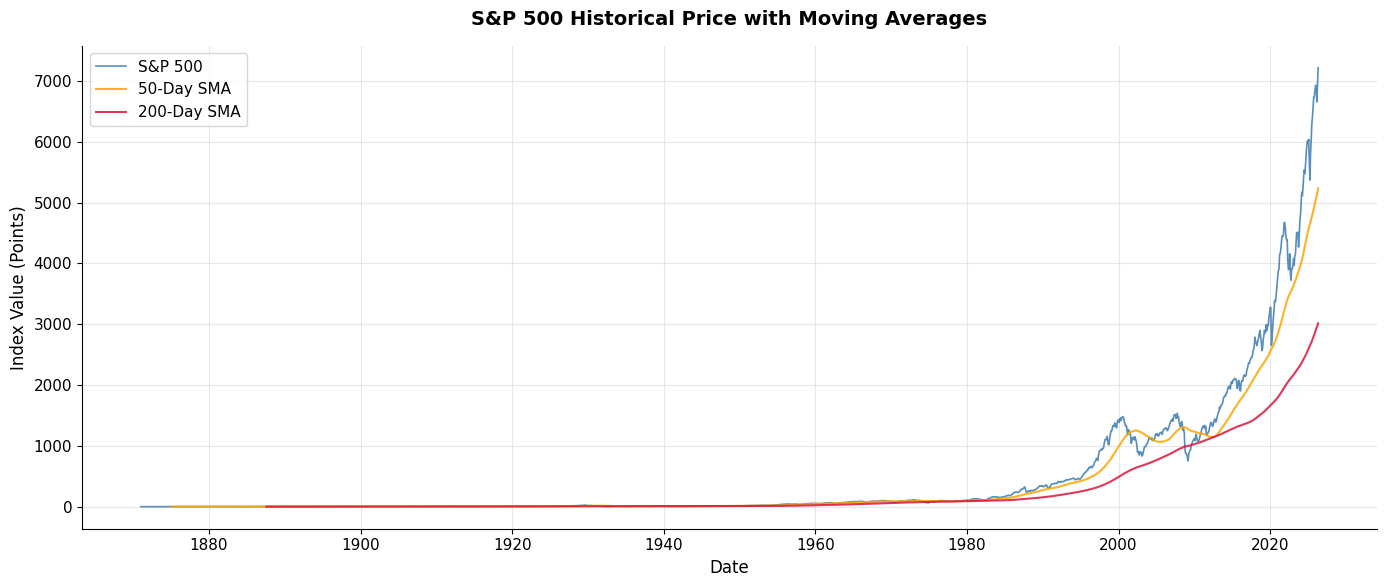

Starting value : 4.44
Ending value   : 7,215.43
Total return   : 162,409.7%


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['Date'], df['SP500'],    color='steelblue',  linewidth=1.2, label='S&P 500',        alpha=0.9)
ax.plot(df['Date'], df['SMA_50'],   color='orange',     linewidth=1.5, label='50-Day SMA',     alpha=0.85)
ax.plot(df['Date'], df['SMA_200'],  color='crimson',    linewidth=1.5, label='200-Day SMA',    alpha=0.85)

ax.set_title('S&P 500 Historical Price with Moving Averages', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Index Value (Points)', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('sp500_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Growth summary
first_val = df['SP500'].iloc[0]
last_val  = df['SP500'].iloc[-1]
total_return = ((last_val - first_val) / first_val) * 100
print(f"Starting value : {first_val:,.2f}")
print(f"Ending value   : {last_val:,.2f}")
print(f"Total return   : {total_return:,.1f}%")

---
## 4. Daily Returns & Extreme Market Events

Daily percentage returns reveal the day-to-day volatility of the market. We identify the **top 5 single-day gains and losses**, which often correspond to major economic events (crashes, crises, recovery rallies).

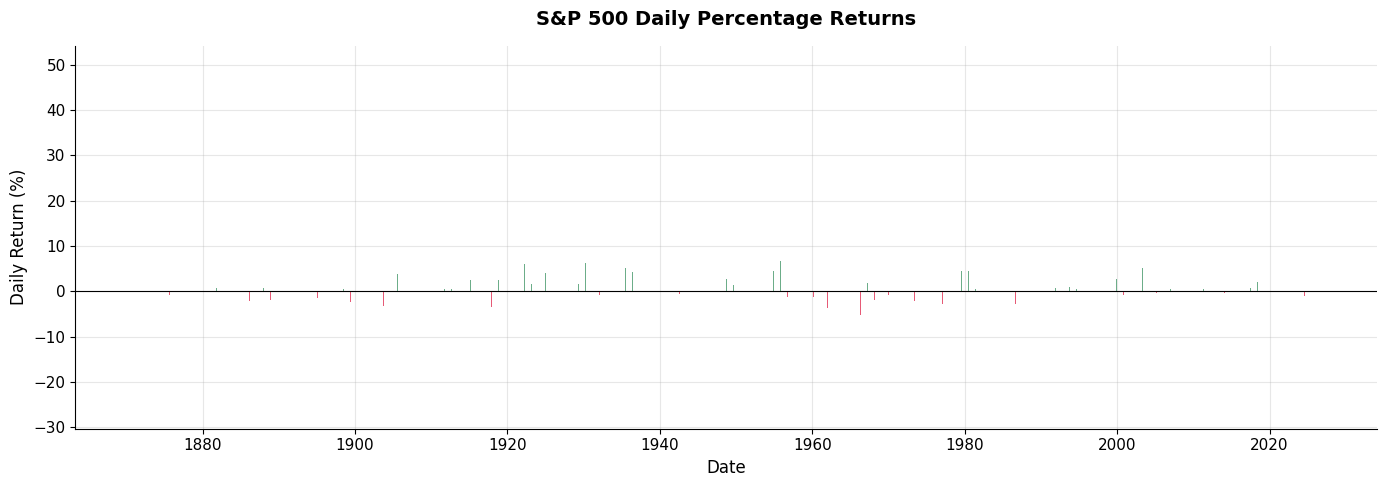

TOP 5 SINGLE-DAY GAINS
      Date  SP500  daily_change  daily_return
1932-08-01   7.53          2.52     50.299401
1933-05-01   8.87          1.98     28.737300
1938-07-01  12.24          2.03     19.882468
1933-06-01  10.39          1.52     17.136415
2009-04-01 848.15         91.02     12.021714

TOP 5 SINGLE-DAY LOSSES
      Date       SP500  daily_change  daily_return
1929-11-01   20.580000     -7.410000    -26.473741
1932-04-01    6.280000     -1.980000    -23.970944
2008-10-01  968.800000   -248.150000    -20.391142
2020-03-01 2652.393636   -624.920574    -19.068070
1931-12-01    8.440000     -1.950000    -18.768046


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['crimson' if x < 0 else 'seagreen' for x in df['daily_return'].fillna(0)]
ax.bar(df['Date'], df['daily_return'], color=colors, width=1.5, alpha=0.7)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('S&P 500 Daily Percentage Returns', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('sp500_daily_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 gains and losses
cols = ['Date', 'SP500', 'daily_change', 'daily_return']
print("=" * 60)
print("TOP 5 SINGLE-DAY GAINS")
print("=" * 60)
print(df.nlargest(5, 'daily_return')[cols].to_string(index=False))

print("\n" + "=" * 60)
print("TOP 5 SINGLE-DAY LOSSES")
print("=" * 60)
print(df.nsmallest(5, 'daily_return')[cols].to_string(index=False))

---
## 5. Return Distribution & Normality Test

A common assumption in finance is that daily returns are **normally distributed**. We visualize the distribution with a histogram and overlay a normal curve, then formally test for normality using the **Shapiro-Wilk test**.

- **H₀**: Daily returns are normally distributed
- **H₁**: Daily returns are not normally distributed

In practice, financial returns tend to have **fat tails** (leptokurtosis) — extreme events occur more frequently than a normal distribution predicts.

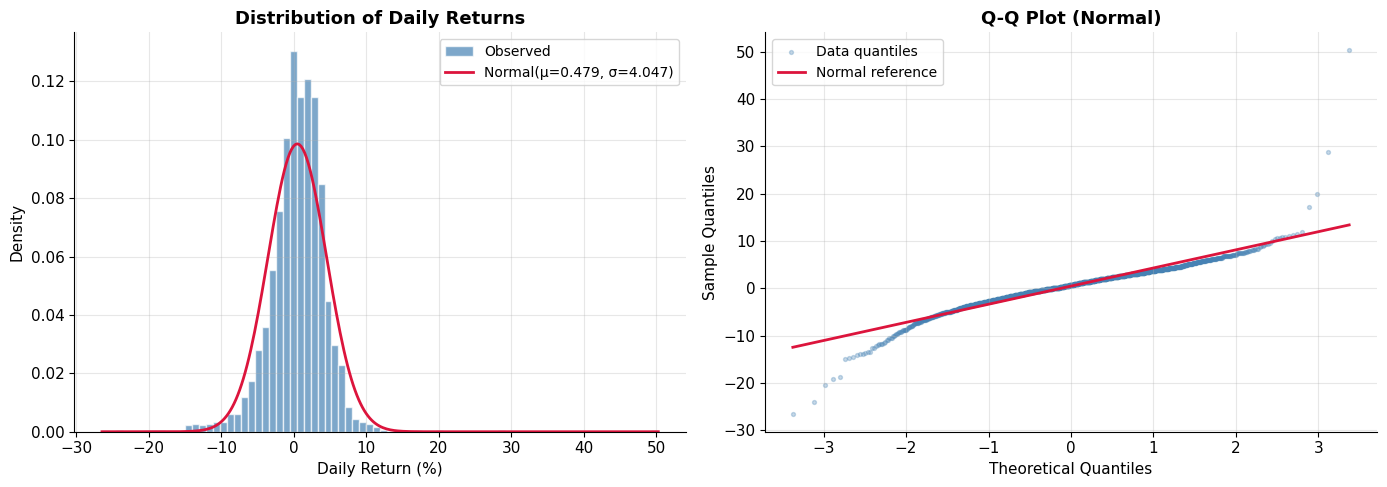

Shapiro-Wilk Test on daily returns (n=1864)
  Test statistic : 0.8992
  p-value        : 0.000000
  Conclusion     : Reject H₀ — returns are NOT normally distributed

Descriptive statistics:
  Mean     : 0.4791%
  Std Dev  : 4.0470%
  Skewness : 0.3728
  Kurtosis : 16.7526  (excess; >0 means fat tails)


In [ ]:
returns_clean = df['daily_return'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal curve overlay
ax1 = axes[0]
ax1.hist(returns_clean, bins=80, color='steelblue', edgecolor='white', alpha=0.7, density=True, label='Observed')
mu, sigma = returns_clean.mean(), returns_clean.std()
x = np.linspace(returns_clean.min(), returns_clean.max(), 300)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), color='crimson', linewidth=2, label=f'Normal(μ={mu:.3f}, σ={sigma:.3f})')
ax1.set_title('Distribution of Daily Returns', fontsize=13, fontweight='bold')
ax1.set_xlabel('Daily Return (%)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.legend(fontsize=10)

# Q-Q Plot
ax2 = axes[1]
sample = returns_clean.sample(min(5000, len(returns_clean)), random_state=42)
(osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
ax2.scatter(osm, osr, alpha=0.3, s=8, color='steelblue', label='Data quantiles')
ax2.plot(osm, slope * np.array(osm) + intercept, color='crimson', linewidth=2, label='Normal reference')
ax2.set_title('Q-Q Plot (Normal)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Theoretical Quantiles', fontsize=11)
ax2.set_ylabel('Sample Quantiles', fontsize=11)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk test (on a sample — Shapiro-Wilk requires n <= 5000)
stat, p_value = stats.shapiro(sample)
print(f"Shapiro-Wilk Test on daily returns (n={len(sample)})")
print(f"  Test statistic : {stat:.4f}")
print(f"  p-value        : {p_value:.6f}")
print(f"  Conclusion     : {'Reject H₀ — returns are NOT normally distributed' if p_value < 0.05 else 'Fail to reject H₀'}")
print(f"\nDescriptive statistics:")
print(f"  Mean     : {mu:.4f}%")
print(f"  Std Dev  : {sigma:.4f}%")
print(f"  Skewness : {returns_clean.skew():.4f}")
print(f"  Kurtosis : {returns_clean.kurtosis():.4f}  (excess; >0 means fat tails)")

---
## 6. Rolling Volatility (1-Year Window)

Rolling volatility (standard deviation of returns over a 252-day window) shows how risk in the market changes over time. Spikes in rolling volatility correspond to periods of economic stress such as the **2008 Financial Crisis** and the **2020 COVID-19 crash**.

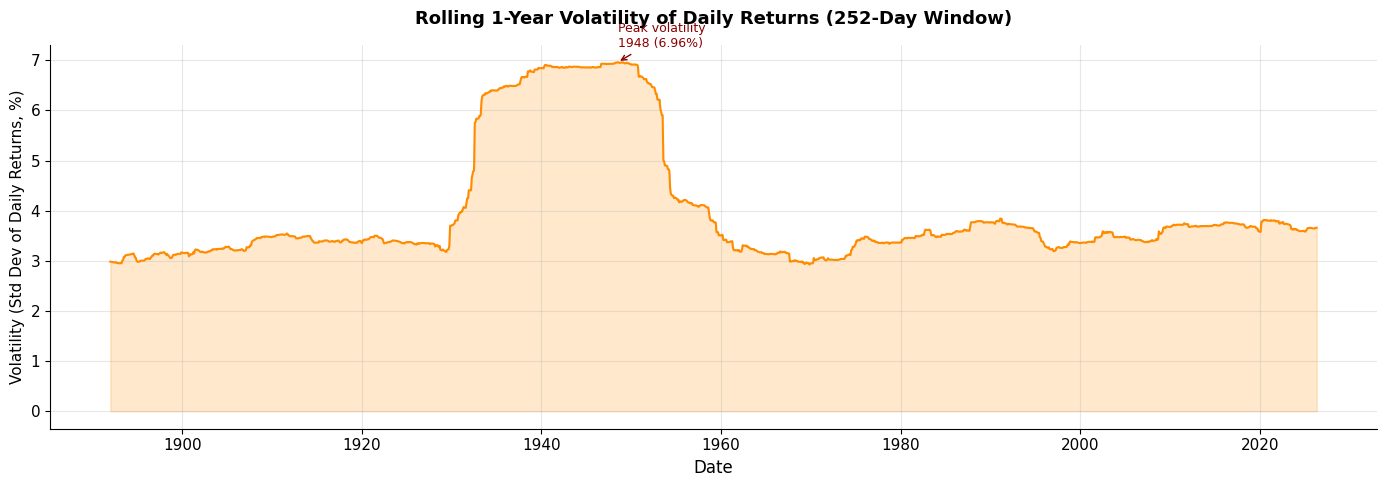

Average annualized volatility: 3.969%
Peak volatility:               6.961% (around 1948-07-01)


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['Date'], df['rolling_vol_252'], color='darkorange', linewidth=1.5)
ax.fill_between(df['Date'], df['rolling_vol_252'], alpha=0.2, color='darkorange')

# Annotate major spikes
peak_idx = df['rolling_vol_252'].idxmax()
peak_date = df.loc[peak_idx, 'Date']
peak_vol  = df.loc[peak_idx, 'rolling_vol_252']
ax.annotate(f'Peak volatility\n{peak_date.year} ({peak_vol:.2f}%)',
            xy=(peak_date, peak_vol), xytext=(peak_date, peak_vol + 0.3),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

ax.set_title('Rolling 1-Year Volatility of Daily Returns (252-Day Window)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (Std Dev of Daily Returns, %)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average annualized volatility: {df['rolling_vol_252'].mean():.3f}%")
print(f"Peak volatility:               {peak_vol:.3f}% (around {peak_date.date()})")

---
## 7. Year-over-Year Annual Returns

We aggregate returns by year to understand which years were strongest and weakest. This is useful for identifying broader economic cycles.

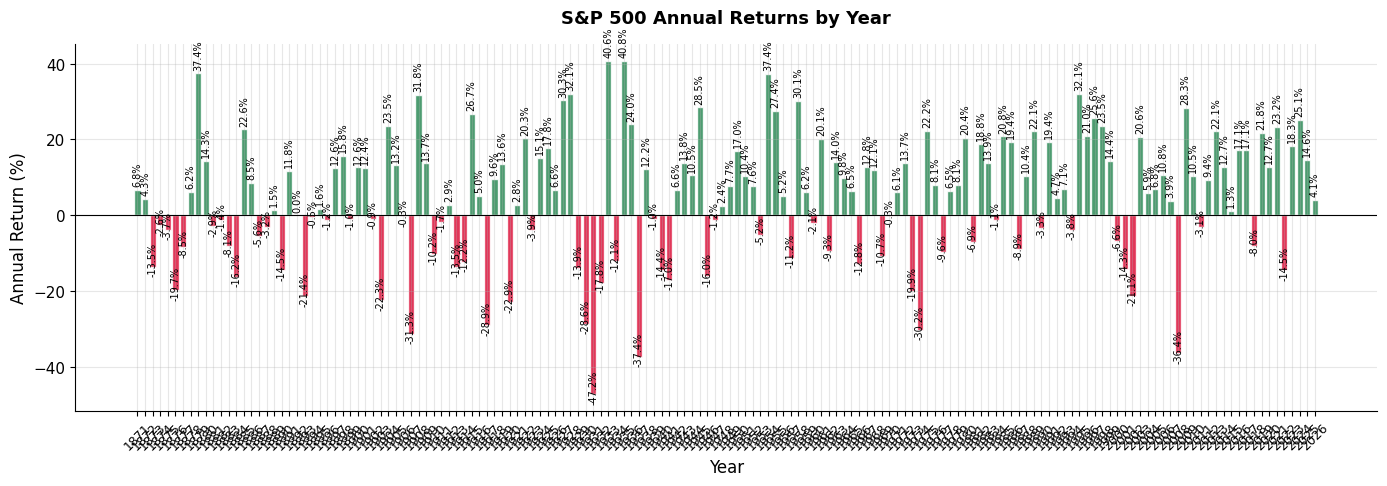

Best year  : 1935  (40.8%)
Worst year : 1931 (-47.2%)
Average annual return: 4.77%
Positive years: 95 / 156


In [ ]:
# Annual return: (last close of year - first close of year) / first close
annual = df.groupby('year')['SP500'].agg(['first', 'last'])
annual['annual_return'] = ((annual['last'] - annual['first']) / annual['first']) * 100
annual = annual.reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ['seagreen' if r >= 0 else 'crimson' for r in annual['annual_return']]
bars = ax.bar(annual['year'], annual['annual_return'], color=bar_colors, edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)

# Label bars
for bar, val in zip(bars, annual['annual_return']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (1 if val >= 0 else -2.5),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_title('S&P 500 Annual Returns by Year', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.set_xticks(annual['year'])
ax.set_xticklabels(annual['year'], rotation=45, fontsize=9)
plt.tight_layout()
plt.savefig('annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()

best  = annual.loc[annual['annual_return'].idxmax()]
worst = annual.loc[annual['annual_return'].idxmin()]
print(f"Best year  : {int(best['year'])}  ({best['annual_return']:.1f}%)")
print(f"Worst year : {int(worst['year'])} ({worst['annual_return']:.1f}%)")
print(f"Average annual return: {annual['annual_return'].mean():.2f}%")
print(f"Positive years: {(annual['annual_return'] > 0).sum()} / {len(annual)}")

---
## 8. Correlation: S&P 500 vs. Long-Term Interest Rate

We examine the relationship between the S&P 500 index level and the long-term interest rate using:
- **Pearson correlation** (linear relationship)
- **Spearman rank correlation** (monotonic relationship, more robust)
- A **linear regression** fit to visualize the trend

Rising interest rates generally increase the cost of borrowing, which can pressure corporate earnings and equity valuations.

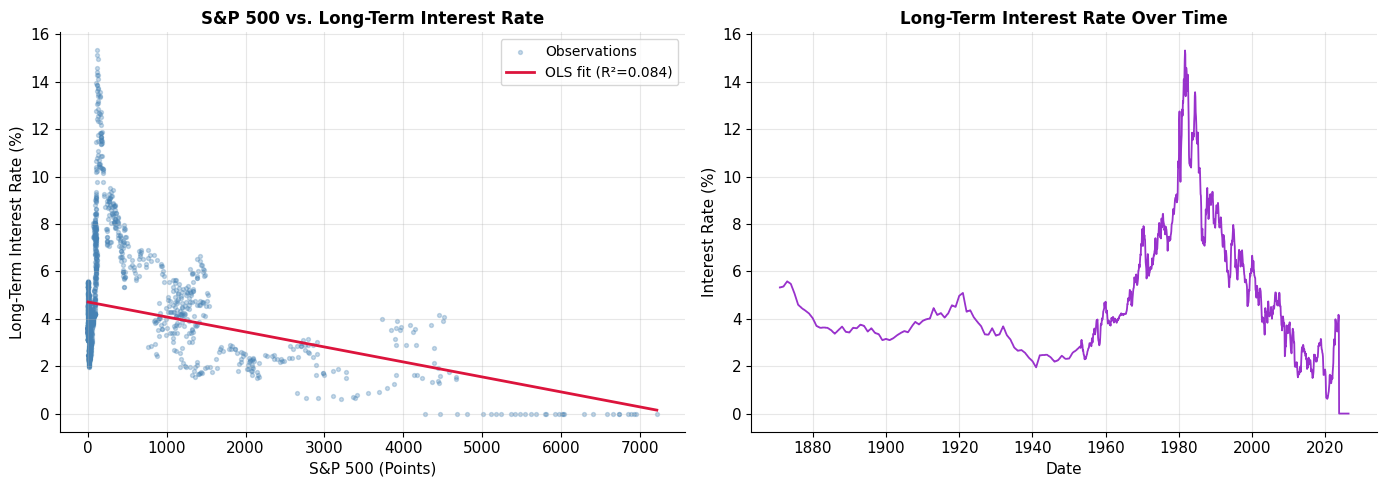

Pearson  correlation : r = -0.2898  (p = 0.0000)
Spearman correlation : r = 0.0787  (p = 0.0007)
Linear regression R² : 0.0840

Interpretation: Statistically significant negative correlation between S&P 500 and long-term interest rates.


In [ ]:
rate_col = 'Long Interest Rate'
corr_df = df[['SP500', rate_col]].dropna()

pearson_r,  p_pearson  = stats.pearsonr(corr_df['SP500'], corr_df[rate_col])
spearman_r, p_spearman = stats.spearmanr(corr_df['SP500'], corr_df[rate_col])

# Linear regression
slope, intercept, r_value, p_val, std_err = stats.linregress(corr_df['SP500'], corr_df[rate_col])
x_line = np.linspace(corr_df['SP500'].min(), corr_df['SP500'].max(), 200)
y_line = slope * x_line + intercept

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter + regression
ax1 = axes[0]
ax1.scatter(corr_df['SP500'], corr_df[rate_col], alpha=0.3, s=8, color='steelblue', label='Observations')
ax1.plot(x_line, y_line, color='crimson', linewidth=2, label=f'OLS fit (R²={r_value**2:.3f})')
ax1.set_title('S&P 500 vs. Long-Term Interest Rate', fontsize=12, fontweight='bold')
ax1.set_xlabel('S&P 500 (Points)', fontsize=11)
ax1.set_ylabel('Long-Term Interest Rate (%)', fontsize=11)
ax1.legend(fontsize=10)

# Time series of interest rate
ax2 = axes[1]
ax2.plot(df['Date'], df[rate_col], color='darkorchid', linewidth=1.3)
ax2.set_title('Long-Term Interest Rate Over Time', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Interest Rate (%)', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson  correlation : r = {pearson_r:.4f}  (p = {p_pearson:.4f})")
print(f"Spearman correlation : r = {spearman_r:.4f}  (p = {p_spearman:.4f})")
print(f"Linear regression R² : {r_value**2:.4f}")
print(f"\nInterpretation: {'Statistically significant' if p_pearson < 0.05 else 'Not statistically significant'} "
      f"{'negative' if pearson_r < 0 else 'positive'} correlation between S&P 500 and long-term interest rates.")

---
## 9. Crash Day Analysis

We define a **crash day** as any day where the S&P 500 drops more than 3% in a single session. We examine how crash days cluster over time and which years experienced the most.

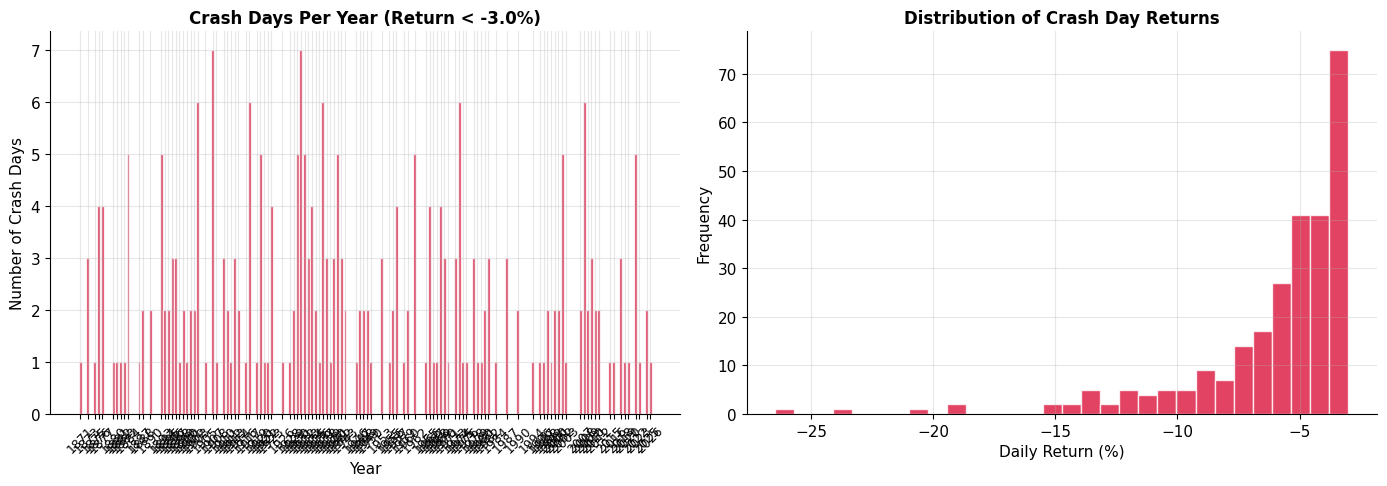

Total crash days (< -3.0%): 266

Worst 10 crash days:
      Date       SP500  daily_return
1929-11-01   20.580000    -26.473741
1932-04-01    6.280000    -23.970944
2008-10-01  968.800000    -20.391142
2020-03-01 2652.393636    -19.068070
1931-12-01    8.440000    -18.768046
1931-09-01   11.830000    -14.892086
1946-09-01   15.090000    -14.745763
1937-10-01   12.280000    -14.544189
1937-09-01   14.370000    -14.157706
1932-10-01    7.120000    -13.801453


In [ ]:
threshold = -3.0  # % drop
crash_days = df[df['daily_return'] < threshold].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crash days per year
crash_by_year = crash_days.groupby('year').size().reset_index(name='crash_count')
axes[0].bar(crash_by_year['year'], crash_by_year['crash_count'], color='crimson', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Crash Days Per Year (Return < {threshold}%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Number of Crash Days', fontsize=11)
axes[0].set_xticks(crash_by_year['year'])
axes[0].set_xticklabels(crash_by_year['year'], rotation=45, fontsize=9)

# Distribution of crash returns
axes[1].hist(crash_days['daily_return'], bins=30, color='crimson', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Crash Day Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)

plt.tight_layout()
plt.savefig('crash_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total crash days (< {threshold}%): {len(crash_days)}")
print(f"\nWorst 10 crash days:")
print(crash_days.nsmallest(10, 'daily_return')[['Date','SP500','daily_return']].to_string(index=False))

---
## 10. Summary & Key Findings

This analysis examined the full historical S&P 500 dataset. Here are the major takeaways:

| Finding | Detail |
|---|---|
| **Long-term growth** | The S&P 500 has delivered substantial total returns over the period analyzed, driven by compounding |
| **Moving averages** | The index spends most of its time above the 200-day SMA, confirming a long-term upward bias |
| **Daily returns** | Returns are approximately bell-shaped but with **fat tails** — the Shapiro-Wilk test rejects normality |
| **Excess kurtosis** | Kurtosis > 0 confirms extreme events occur more often than a normal model would predict |
| **Volatility clustering** | Rolling volatility spikes sharply during crises (2008, 2020) then reverts to lower levels |
| **Annual returns** | The market posts positive annual returns the majority of years, consistent with historical literature |
| **Interest rates** | There is a statistically significant correlation between the S&P 500 and long-term interest rates |
| **Crash days** | Crash days (< -3%) cluster around known economic downturns |

### Limitations
- This analysis uses **index-level data only** — individual stock behavior can differ significantly
- Correlation ≠ causation — the interest rate relationship may be confounded by macroeconomic conditions
- The dataset reflects **closing prices only** — intraday volatility is not captured

### Potential Extensions
- Add **sector-level** analysis to see which industries drive volatility
- Build a simple **predictive model** using lagged returns and interest rates
- Incorporate **inflation data** to calculate real (inflation-adjusted) returns